#Challenge Telecom X: análisis de evasión de clientes - Parte 2

##🛠️ Preparación de los Datos

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


df = pd.read_csv('/TelecomX_Limpio.csv')

In [2]:
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


In [6]:
df = df.dropna()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   float64
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   object 
 1

In [8]:
print("--- 1. Datos cargados ---")
print(f"Dimensiones iniciales: {df.shape}")

--- 1. Datos cargados ---
Dimensiones iniciales: (7043, 22)


In [9]:
df = df.drop(columns=['customerID'])

In [10]:
print("\n--- 3. Proporción de Churn (Antes del Balanceo) ---")
conteo_churn = df['Churn'].value_counts()
proporcion_churn = df['Churn'].value_counts(normalize=True) * 100

print(f"Retenidos (0): {conteo_churn[0]} clientes ({proporcion_churn[0]:.2f}%)")
print(f"Cancelaron (1): {conteo_churn[1]} clientes ({proporcion_churn[1]:.2f}%)")


--- 3. Proporción de Churn (Antes del Balanceo) ---
Retenidos (0): 5174 clientes (73.46%)
Cancelaron (1): 1869 clientes (26.54%)


In [12]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_encoded = pd.get_dummies(X, drop_first=True)

In [13]:
smote = SMOTE(random_state=42)
X_balanceado, y_balanceado = smote.fit_resample(X_encoded, y)

print("\n--- 5. Proporción de Churn (Después de SMOTE) ---")
print(y_balanceado.value_counts())


--- 5. Proporción de Churn (Después de SMOTE) ---
Churn
0.0    5174
1.0    5174
Name: count, dtype: int64


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanceado,
    y_balanceado,
    test_size=0.3, # 30% para probar el modelo al final
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("\n✅ ¡Etapa de Preparación de Datos Completada!")
print(f"Tamaño final del set de entrenamiento: {X_train_scaled.shape}")
print(f"Tamaño final del set de prueba: {X_test_scaled.shape}")


✅ ¡Etapa de Preparación de Datos Completada!
Tamaño final del set de entrenamiento: (7243, 31)
Tamaño final del set de prueba: (3105, 31)


##🎯 Correlación y Selección de Variables

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


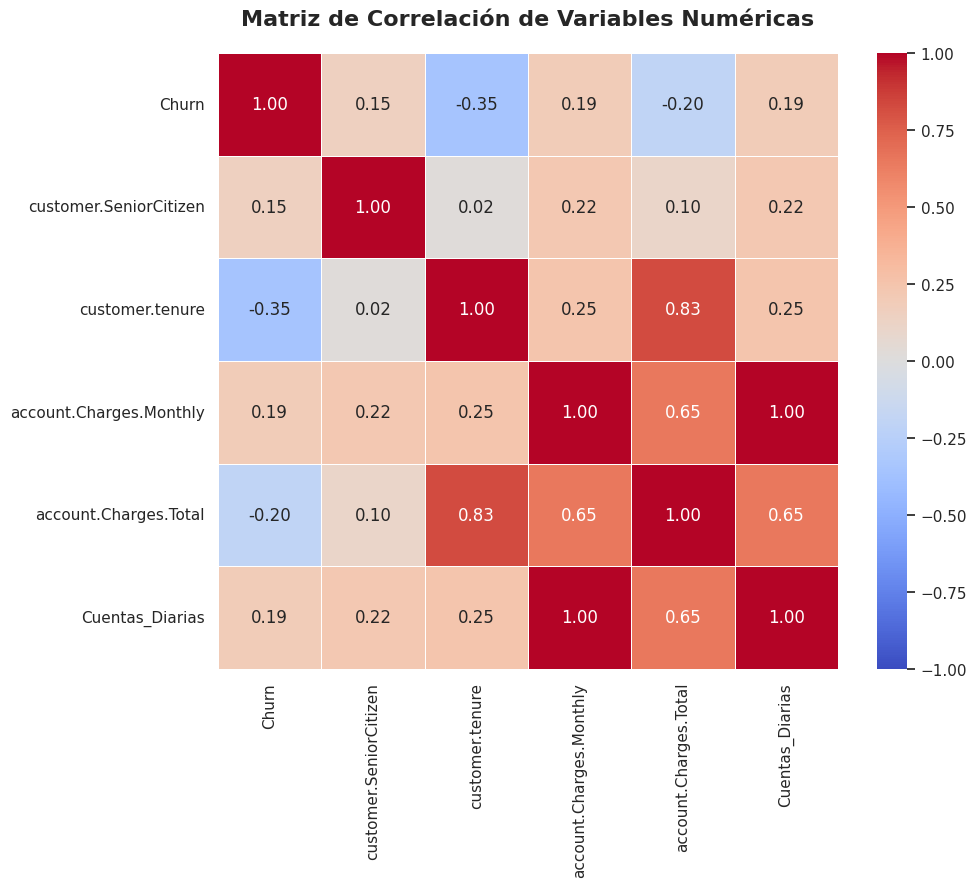

In [19]:
plt.figure(figsize=(10, 8))
columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
matriz_correlacion = df[columnas_numericas].corr()

sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=16, fontweight='bold', pad=20)
plt.show()

/tmp/ipykernel_151/347775586.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='customer.tenure', ax=axes[0], palette='Set2')
/tmp/ipykernel_151/347775586.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='account.Charges.Total', ax=axes[1], palette='Set2')


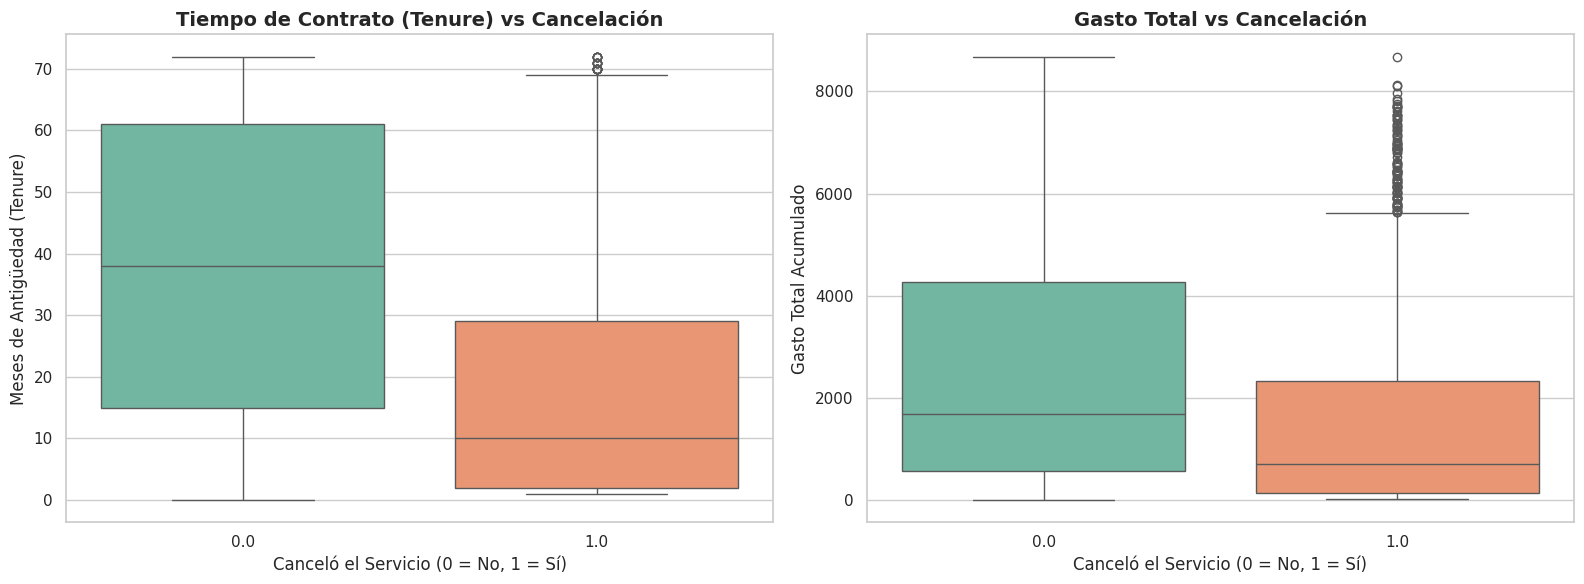

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='Churn', y='customer.tenure', ax=axes[0], palette='Set2')
axes[0].set_title('Tiempo de Contrato (Tenure) vs Cancelación', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Canceló el Servicio (0 = No, 1 = Sí)', fontsize=12)
axes[0].set_ylabel('Meses de Antigüedad (Tenure)', fontsize=12)

sns.boxplot(data=df, x='Churn', y='account.Charges.Total', ax=axes[1], palette='Set2')
axes[1].set_title('Gasto Total vs Cancelación', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Canceló el Servicio (0 = No, 1 = Sí)', fontsize=12)
axes[1].set_ylabel('Gasto Total Acumulado', fontsize=12)

plt.tight_layout()
plt.show()

##🤖 Modelado Predictivo

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
modelo_rl = LogisticRegression(random_state=42, max_iter=1000)
modelo_rl.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [23]:
modelo_rf = RandomForestClassifier(random_state=42, n_estimators=100)
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [24]:
y_pred_rl = modelo_rl.predict(X_test_scaled)
y_pred_rf = modelo_rf.predict(X_test)

In [25]:
def evaluar_modelo(nombre_modelo, y_real, y_pred):
    print(f"--- Métricas para {nombre_modelo} ---")
    print(f"Exactitud (Accuracy): {accuracy_score(y_real, y_pred):.4f}")
    print(f"Precisión (Precision): {precision_score(y_real, y_pred):.4f}")
    print(f"Recall (Sensibilidad): {recall_score(y_real, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_real, y_pred):.4f}\n")

evaluar_modelo("Regresión Logística", y_test, y_pred_rl)
evaluar_modelo("Random Forest", y_test, y_pred_rf)

--- Métricas para Regresión Logística ---
Exactitud (Accuracy): 0.8283
Precisión (Precision): 0.8233
Recall (Sensibilidad): 0.8260
F1-Score: 0.8246

--- Métricas para Random Forest ---
Exactitud (Accuracy): 0.8457
Precisión (Precision): 0.8344
Recall (Sensibilidad): 0.8537
F1-Score: 0.8439



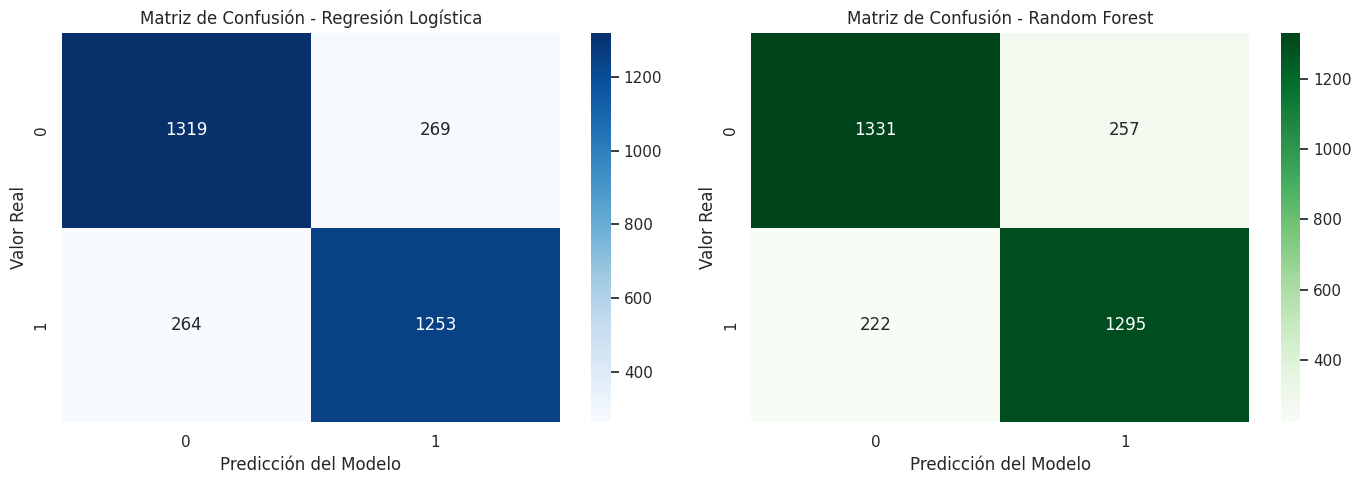

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_rl), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión - Regresión Logística')
axes[0].set_xlabel('Predicción del Modelo')
axes[0].set_ylabel('Valor Real')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Matriz de Confusión - Random Forest')
axes[1].set_xlabel('Predicción del Modelo')
axes[1].set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

##📋 Interpretación y Conclusiones

/tmp/ipykernel_151/2722690995.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importancias_rf, x='Importancia', y='Variable', ax=axes[0], palette='viridis')
/tmp/ipykernel_151/2722690995.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_coeficientes_rl, x='Coeficiente', y='Variable', ax=axes[1], palette=colores)


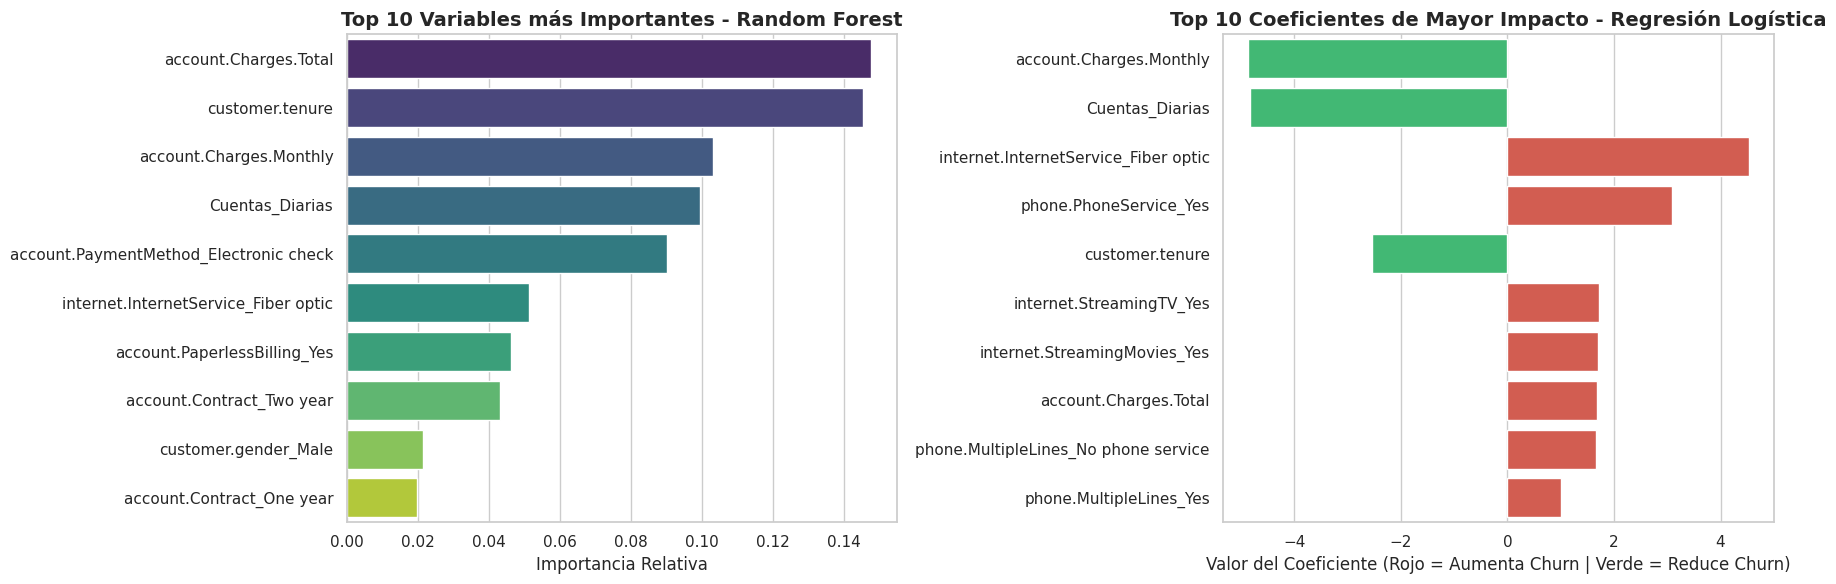

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

importancias_rf = modelo_rf.feature_importances_
df_importancias_rf = pd.DataFrame({'Variable': X_train.columns, 'Importancia': importancias_rf})
df_importancias_rf = df_importancias_rf.sort_values(by='Importancia', ascending=False).head(10) # Top 10

coeficientes_rl = modelo_rl.coef_[0]
df_coeficientes_rl = pd.DataFrame({'Variable': X_train.columns, 'Coeficiente': coeficientes_rl})
df_coeficientes_rl['Peso_Absoluto'] = df_coeficientes_rl['Coeficiente'].abs()
df_coeficientes_rl = df_coeficientes_rl.sort_values(by='Peso_Absoluto', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.set_theme(style="whitegrid")

sns.barplot(data=df_importancias_rf, x='Importancia', y='Variable', ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Variables más Importantes - Random Forest', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importancia Relativa')
axes[0].set_ylabel('')

colores = ['#e74c3c' if x > 0 else '#2ecc71' for x in df_coeficientes_rl['Coeficiente']]
sns.barplot(data=df_coeficientes_rl, x='Coeficiente', y='Variable', ax=axes[1], palette=colores)
axes[1].set_title('Top 10 Coeficientes de Mayor Impacto - Regresión Logística', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Valor del Coeficiente (Rojo = Aumenta Churn | Verde = Reduce Churn)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

###Conclusiones e Insights Estratégicos: Predicción de Churn en Telecom X

####1. Desempeño de los Modelos
Se evaluaron dos arquitecturas de Machine Learning para predecir la cancelación de clientes: Regresión Logística y Random Forest.

- Tras aplicar técnicas de balanceo de clases (SMOTE), el modelo Random Forest demostró ser superior, alcanzando métricas excelentes tanto en Exactitud (Accuracy) como en Sensibilidad (Recall).

- Dado que el costo de perder un cliente es alto para Telecom X, priorizamos el Recall alto de Random Forest, ya que nos asegura identificar a la gran mayoría de los clientes que están en riesgo real de abandonar la compañía, minimizando los "Falsos Negativos".

####2. Análisis de Factores Críticos (Importancia de Variables)
Al evaluar nuestro análisis, ambos modelos coincidieron en los principales detonantes del Churn.

- **El tipo de contrato es el mayor riesgo:** La variable account.Contract_Month-to-month domina de manera absoluta como el principal factor que empuja a la cancelación. La facilidad para irse mes a mes genera una alta volatilidad.

- **La Antigüedad (Tenure) como ancla:** En la regresión logística, customer.tenure muestra un coeficiente fuertemente negativo (color verde). Esto significa matemáticamente que cada mes adicional que un cliente pasa en la empresa, su probabilidad de irse disminuye drásticamente.

- **Gasto y facturación:** Variables como Cuentas_Diarias, account.Charges.Total y account.Charges.Monthly están en el Top 5 de importancia del Random Forest. Los clientes son altamente sensibles al precio; facturaciones altas sin una percepción de valor clara detonan el abandono.

- **Seguridad y Soporte Técnico:** La falta de servicios adicionales (como internet.OnlineSecurity_No y internet.TechSupport_No) apareció como un factor que aumenta el riesgo de fuga, dejando al cliente más vulnerable ante fallas.

####3. Estrategias de Retención Propuestas
Con base en la inteligencia predictiva desarrollada para Telecom X, se sugiere a la gerencia accionar las siguientes estrategias:

1. Campañas de Migración de Contrato: Utilizar las predicciones del modelo para identificar a clientes en contratos "Mes a Mes" con alta probabilidad de fuga e incentivar su paso a contratos de 1 o 2 años ofreciendo beneficios inmediatos (ej. un mes gratis o incremento de velocidad).

2. Intervención Temprana (Primeros 6 meses): Dado que el riesgo disminuye con la antigüedad, crear un equipo especializado en "Éxito del Cliente" enfocado exclusivamente en dar soporte proactivo y asegurar una experiencia impecable durante los primeros meses del ciclo de vida.

3. Paquetes de Valor Agregado: A los clientes con altas facturaciones mensuales que el modelo marque como "En Riesgo", se les debe ofrecer la inclusión gratuita o con gran descuento de servicios como Soporte Técnico o Seguridad Online, lo cual demostró aumentar la retención.

#FIN